In [1]:
import math
import random
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Для нормализации данных и расчета метрик
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Настройка визуализации и вывода
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(19)

# Определяем устройство: используем GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Данные и первичный анализ

In [3]:
df = pd.read_csv('data/S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
# Привести колонку date к datetime и отсортировать по времени
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [5]:
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [6]:
print("Число наблюдений:", len(df))
print("Диапазон дат:", df['date'].min(), "–", df['date'].max())
print("\nЧисло пропусков по колонкам:")
print(df.isna().sum())

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 – 2025-06-29 23:00:00

Число пропусков по колонкам:
date      0
target    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


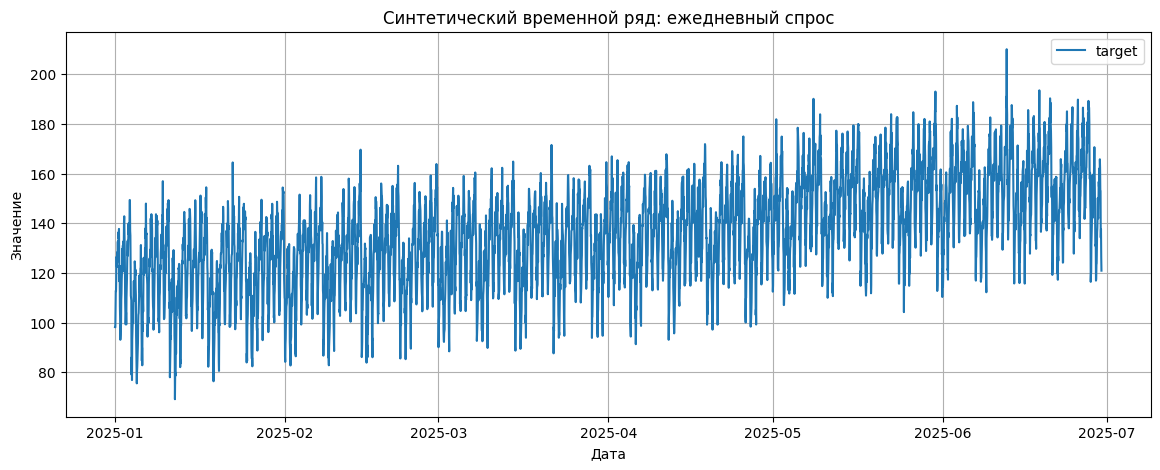

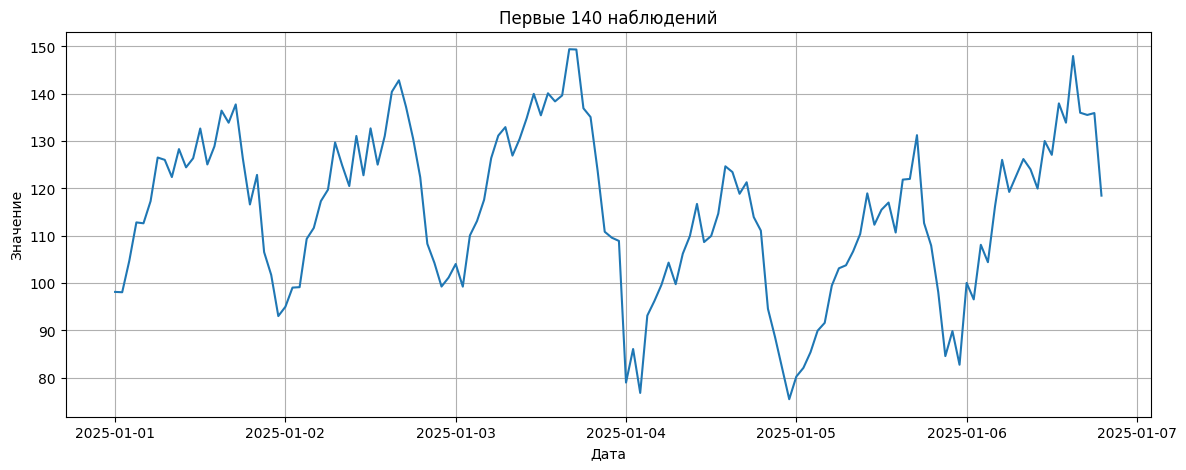

In [7]:
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.5, label="target")
ax.set_title("Синтетический временной ряд: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(df["date"].iloc[:140], df["target"].iloc[:140], lw=1.5)
ax.set_title("Первые 140 наблюдений")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
plt.show()

Временной ряд target имеет возрастающий падающий тренд, видимые недельные циклы указывают на сезонность. В ряде наблюдаются отдельные выбросы, которые могут влиять на модели. Поведение дисперсии и среднего во времени указывает на нестационарность, поэтому для моделирования будут целесообразны дифференцирование или стационарные спецификации.

### Корректный temporal split

In [8]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


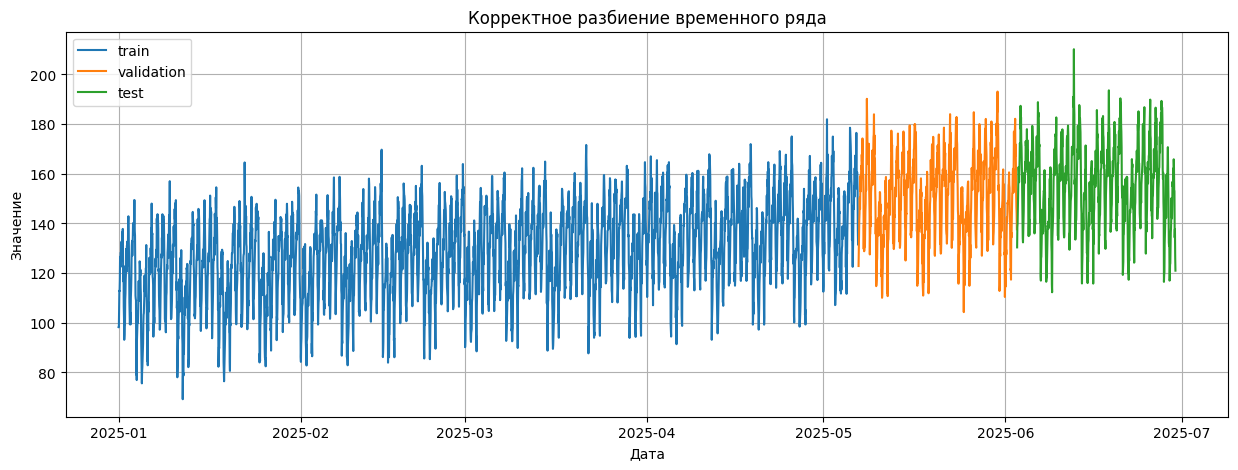

In [9]:
# визуализация разбиения
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/series_split.png")

### Почему Random Split некорректен для временных рядов?

**Random split не подходит в случае временных рядов**, поскольку для временного ряда мы обязаны сохранять хронологический порядок: модель должна учиться на прошлом и проверяться на будущем.

При Random split:
- Модель может "заглянуть в будущее" (data leakage)
- Нарушается временная зависимость данных
- Метрики на валидации не будут отражать реальное качество модели

**Правильный подход:** Temporal split - разбиение по времени (train → val → test)

### Признаки для baseline-моделей

In [10]:
def make_time_features(dataframe):
    data = dataframe.copy()
    
    data["lag_1"] = data["target"].shift(1)
    data["lag_7"] = data["target"].shift(7)
    data["lag_14"] = data["target"].shift(14)
    
    data["rolling_mean_7"] = data["target"].shift(1).rolling(7).mean()
    data["rolling_std_7"] = data["target"].shift(1).rolling(7).std()
    
    data["month"] = data["date"].dt.month
    
    return data

featured_df = make_time_features(df)
featured_df.head(20)

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,month
0,2025-01-01 00:00:00,98.14,NaN,NaN,NaN,NaN,NaN,1
1,2025-01-01 01:00:00,98.07,98.14,NaN,NaN,NaN,NaN,1
2,2025-01-01 02:00:00,104.70,98.07,NaN,NaN,NaN,NaN,1
3,2025-01-01 03:00:00,112.81,104.70,NaN,NaN,NaN,NaN,1
4,2025-01-01 04:00:00,112.62,112.81,NaN,NaN,NaN,NaN,1
5,2025-01-01 05:00:00,117.29,112.62,NaN,NaN,NaN,NaN,1
6,2025-01-01 06:00:00,126.50,117.29,NaN,NaN,NaN,NaN,1
7,2025-01-01 07:00:00,126.01,126.50,98.14,NaN,110.018571,10.418147,1
8,2025-01-01 08:00:00,122.38,126.01,98.07,NaN,114.000000,10.447405,1
9,2025-01-01 09:00:00,128.28,122.38,104.70,NaN,117.472857,8.030400,1


In [11]:
featured_df = featured_df.dropna().reset_index(drop=True)

n_feat = len(featured_df)
train_end_feat = int(n_feat * 0.70)
val_end_feat = int(n_feat * 0.85)

train_feat = featured_df.iloc[:train_end_feat].copy()
val_feat = featured_df.iloc[train_end_feat:val_end_feat].copy()
test_feat = featured_df.iloc[val_end_feat:].copy()

feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "month",
]

target_col = "target"

print("Feature columns:", feature_cols)
print(train_feat.shape, val_feat.shape, test_feat.shape)

Feature columns: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'month']
(3014, 8) (646, 8) (646, 8)


In [12]:
train_feat, val_feat, test_feat = temporal_split(featured_df)

X_train_base = train_feat[feature_cols]
y_train_base = train_feat[target_col]

X_val_base = val_feat[feature_cols]
y_val_base = val_feat[target_col]

X_test_base = test_feat[feature_cols]
y_test_base = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train_base.shape, "| y_train:", y_train_base.shape)
print("X_val:  ", X_val_base.shape, "| y_val:  ", y_val_base.shape)
print("X_test: ", X_test_base.shape, "| y_test: ", y_test_base.shape)

Размерности:
X_train: (3014, 6) | y_train: (3014,)
X_val:   (646, 6) | y_val:   (646,)
X_test:  (646, 6) | y_test:  (646,)


### Оконное представление для GRU

In [13]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)        # transform на val
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)      # transform на test


In [14]:
window_size = 70  # глубина окна, можно менять

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2954, 70, 1) y_train: (2954,)
X_val  : (578, 70, 1) y_val  : (578,)
X_test : (578, 70, 1) y_test : (578,)


Форма одного окна: (70, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -1.0078033


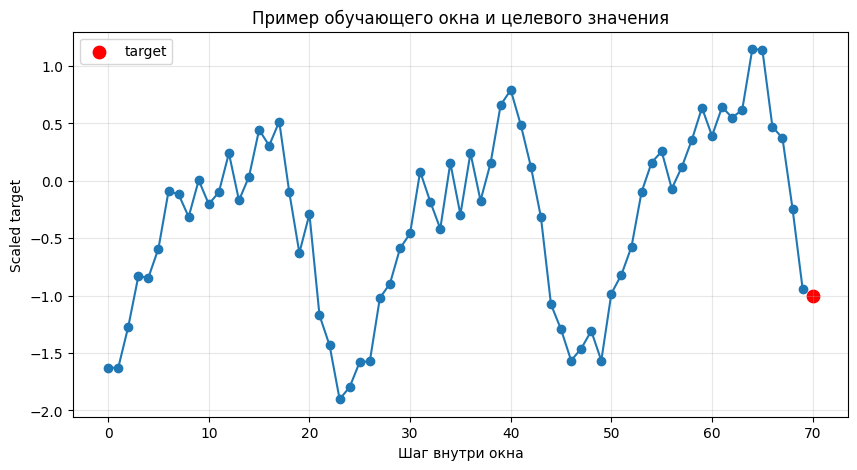

In [15]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, c="red", label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled target")
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]  # (window_size, 1), float

batch_size = 64

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds   = TimeSeriesDataset(X_val,   y_val)
test_ds  = TimeSeriesDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# Проверка формы батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)


Batch X: torch.Size([64, 70, 1])
Batch y: torch.Size([64])


### Базовые функции обучения и оценки

In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device): # Обучает модель на одной эпохе.
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device): # Оценивает модель на валидации/тесте без обновления весов.
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device): #  Полный цикл обучения с ранней остановкой.
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

## Обязательные эксперименты

In [18]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # +epsilon чтобы избежать деления на 0
    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
    }


def append_run_to_csv(run: dict, csv_path: str = "artifacts/runs.csv"):
    run_df = pd.DataFrame([run])
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        run_df = pd.concat([existing, run_df], ignore_index=True)
    run_df.to_csv(csv_path, index=False)

### B1: naive-last

In [19]:
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

b1_val = evaluate_regression(y_val_base, val_pred_naive, "Naive (lag_1)")

display(b1_val)

,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594


### B2: moving-average

In [20]:
# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

b2_val = evaluate_regression(y_val_base, val_pred_ma7, "MovingAverage(7)")

display(b2_val)

,model,MAE,RMSE,MAPE_%
0,MovingAverage(7),12.723717,15.236326,8.828779


### B3: Ridge на lag/rolling/календарных признаках

In [21]:
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train_base)  # fit на train
X_val_scaled = scaler_features.transform(X_val_base)          # transform на val
X_test_scaled = scaler_features.transform(X_test_base)        # transform на test

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_base)

Ridge()

In [23]:
val_pred_ridge = ridge.predict(X_val_scaled)

In [24]:
b3_val = evaluate_regression(y_val_base, val_pred_ridge, "Ridge")
display(b3_val)

,model,MAE,RMSE,MAPE_%
0,Ridge,6.363281,7.94012,4.28563


In [25]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'weight': ridge.coef_
}).sort_values('weight', key=abs, ascending=False)
print(feature_importance.to_string(index=False, formatters={'weight': '{:+.4f}'.format}))

       feature   weight
         lag_1 +17.2155
rolling_mean_7  -2.4369
         month  +1.7187
 rolling_std_7  -1.5703
         lag_7  -0.4061
        lag_14  -0.0960


###  R1: GRU на оконном представлении

In [26]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [27]:
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7845 | val_loss=0.6281
Epoch 02 | train_loss=0.4611 | val_loss=0.3262
Epoch 03 | train_loss=0.2289 | val_loss=0.1706
Epoch 04 | train_loss=0.1753 | val_loss=0.1579
Epoch 05 | train_loss=0.1632 | val_loss=0.1540
Epoch 06 | train_loss=0.1588 | val_loss=0.1535
Epoch 07 | train_loss=0.1563 | val_loss=0.1540
Epoch 08 | train_loss=0.1547 | val_loss=0.1549
Epoch 09 | train_loss=0.1534 | val_loss=0.1558
Epoch 10 | train_loss=0.1521 | val_loss=0.1565
Epoch 11 | train_loss=0.1507 | val_loss=0.1569
Epoch 12 | train_loss=0.1490 | val_loss=0.1570
Epoch 13 | train_loss=0.1469 | val_loss=0.1564
Epoch 14 | train_loss=0.1440 | val_loss=0.1541
Epoch 15 | train_loss=0.1392 | val_loss=0.1471
Epoch 16 | train_loss=0.1307 | val_loss=0.1332
Epoch 17 | train_loss=0.1192 | val_loss=0.1226
Epoch 18 | train_loss=0.1113 | val_loss=0.1183
Epoch 19 | train_loss=0.1079 | val_loss=0.1140
Epoch 20 | train_loss=0.1060 | val_loss=0.1118
Epoch 21 | train_loss=0.1043 | val_loss=0

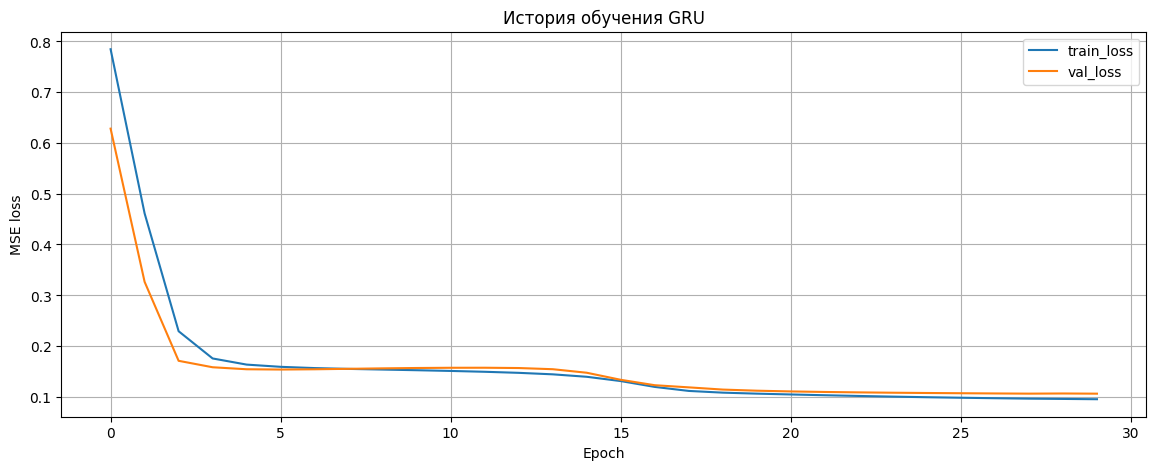

In [28]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")

In [29]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


In [30]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("RMSE")

val_metrics

,model,MAE,RMSE,MAPE
0,GRU,4.75568,6.192065,3.254138


По метрике MAE лучшей моделью является R1

In [31]:
scaler_target = StandardScaler()
train_scaled = scaler_target.fit_transform(train_df["target"].values.reshape(-1, 1)).astype(np.float32)
val_scaled = scaler_target.transform(val_df["target"].values.reshape(-1, 1)).astype(np.float32)
test_scaled = scaler_target.transform(test_df["target"].values.reshape(-1, 1)).astype(np.float32)

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

# обратно в исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler_target)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler_target)

# оценка метрик
test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)}
    ]
).sort_values("RMSE")
test_metrics


,model,MAE,RMSE,MAPE
0,GRU,5.250839,6.760443,3.427096


In [32]:
b4_val = val_metrics.rename(columns={"MAE": "MAE", "RMSE": "RMSE", "MAPE": "MAPE_%"})
b4_test = test_metrics.rename(columns={"MAE": "MAE", "RMSE": "RMSE", "MAPE": "MAPE_%"})

In [33]:
def make_run_row(
    exp_id: str,
    model_name: str,
    val_eval_df: pd.DataFrame,
    notes: str,
    test_eval_df: pd.DataFrame = None,
):
    """
    val_eval_df, test_eval_df — это результаты evaluate_regression(...) для одной модели.
    """
    row = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 19,
        "split_summary": "train=3024, val=648, test=648",
        "window_size": (
            70 if exp_id == "R1" else 
            7 if exp_id == "B2"
            else None
        ),
        "horizon": 1,
        "model_summary": (
            "GRU (input_size=1, hidden_size=64, num_layers=2, dropout=0.0, head=Linear)"
            if exp_id == "R1" else
            "Ridge" if exp_id == "B3" else
            "Naive (lag_1)" if exp_id == "B1" else
            "MovingAverage(7)" if exp_id == "B2" else
            model_name
        ),
        "features_summary": (
            "windowed target (no extra features)" if exp_id == "R1" else
            "lag_1, lag_7, lag_14; rolling_mean_7, std_7; dayofweek,month,hour, sin/cos"
            if exp_id == "B3" else
            "lag_1" if exp_id == "B1" else
            "rolling_mean_7" if exp_id == "B2" else
            "unknown"
        ),
        "scaler": "StandardScaler" if exp_id in ["B3", "R1"] else "None",
        "optimizer": "Adam" if exp_id == "R1" else "None",
        "lr": 5e-4 if exp_id == "R1" else "None",
        "epochs_trained": 30 if exp_id == "R1" else 0,
        "best_val_mae": val_eval_df["MAE"].iloc[0],
        "best_val_rmse": val_eval_df["RMSE"].iloc[0],
        "best_val_mape": val_eval_df["MAPE_%"].iloc[0],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": notes,
    }

    # если test_eval_df передан и не пустой, заполняем тестовые метрики
    if test_eval_df is not None and not test_eval_df.empty:
        row["test_mae"]   = test_eval_df["MAE"].iloc[0]
        row["test_rmse"]  = test_eval_df["RMSE"].iloc[0]
        row["test_mape"]  = test_eval_df["MAPE_%"].iloc[0]
        
    return row


In [34]:
runs = []

runs.append(make_run_row("B1", "Naive (lag_1)", b1_val, "Наивная модель ‘last value’ baseline: предсказание равно последнему наблюдённому значению (lag_1)"))
runs.append(make_run_row("B2", "MovingAverage(7)", b2_val, "Служит более сильным базовым бенчмарком, чем наивная модель, особенно если есть выраженная локальная сезонность."))
runs.append(make_run_row("B3", "Ridge", b3_val, "Использует лаги (lag_1, lag_7, lag_14), скользящие статистики rolling_mean_7/rolling_std_7, а также день недели, месяц, час"))
runs.append(make_run_row("R1", "GRU", b4_val, "GRU на оконном представлении временного ряда длины 70 шагов.", b4_test))

runs_df = pd.DataFrame(runs)
runs_df.to_csv("artifacts/runs.csv", index=False)

In [35]:
best_gru_path = "artifacts/best_gru.pt"
torch.save(gru_model.state_dict(), best_gru_path)

print("GRU.state_dict() сохранён:", best_gru_path)

GRU.state_dict() сохранён: artifacts/best_gru.pt


In [36]:
best_gru_config = {
    "task": "forecasting",
    "model": "GRUForecaster",
    "window_size": 28,
    "horizon": 1,
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "batch_size": 64,
    "optimizer": "Adam",
    "lr": 5e-4,
    "epochs_trained": 30,
    "seed": 42,
    "scaler_type": "StandardScaler",
    "target_column": "target",
}

best_gru_config_path = "artifacts/best_gru_config.json"
with open(best_gru_config_path, "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

print("Конфиг GRU сохранён:", best_gru_config_path)

Конфиг GRU сохранён: artifacts/best_gru_config.json


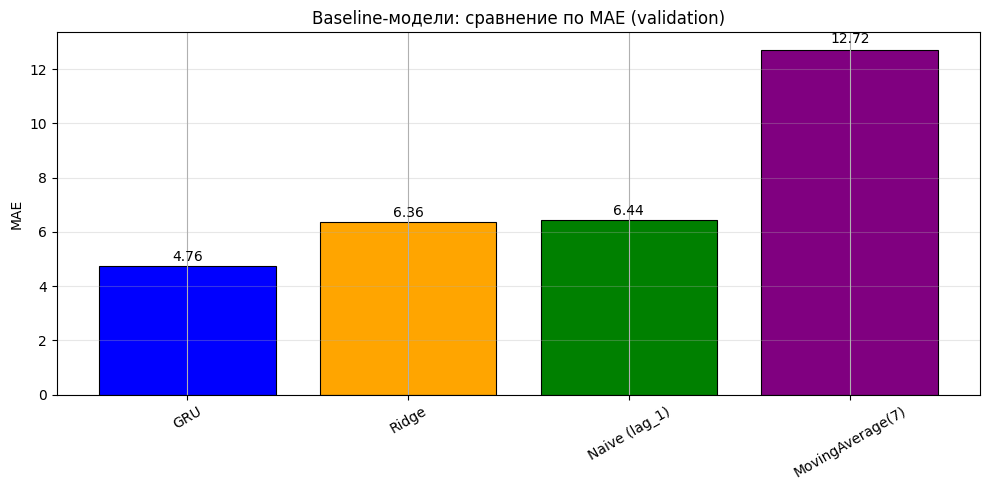

In [37]:
val_results = val_results = pd.concat([
    b1_val, b2_val, b3_val, b4_val,
], ignore_index=True).sort_values("MAE").reset_index(drop=True)
val_results_sorted = val_results.sort_values("MAE")

plt.figure(figsize=(10, 5))

bars = plt.bar(
    val_results_sorted["model"],
    val_results_sorted["MAE"],
    color=["blue", "orange", "green", "purple"],
    edgecolor="k",
    linewidth=0.8,
)

plt.title("Baseline-модели: сравнение по MAE (validation)")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)

for bar, mae in zip(bars, val_results_sorted["MAE"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * bar.get_height(),
             f"{mae:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")

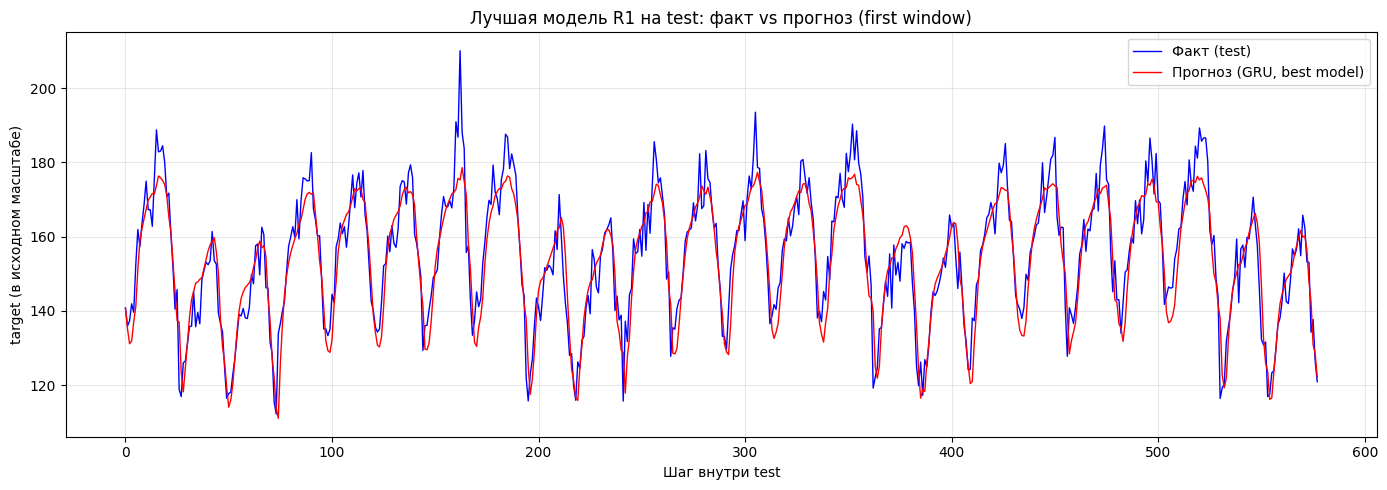

In [38]:
plt.figure(figsize=(14, 5))

plt.plot(test_true,    label="Факт (test)", c="blue", lw=1)
plt.plot(gru_test_pred, label="Прогноз (GRU, best model)", c="red", lw=1)

plt.title(f"Лучшая модель R1 на test: факт vs прогноз (first window)")
plt.xlabel("Шаг внутри test")
plt.ylabel("target (в исходном масштабе)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png")